In [31]:
import numpy as np
import pandas as pd
from scipy.stats import mode
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from imblearn.over_sampling import RandomOverSampler


In [32]:
data = pd.read_csv(r"C:\Users\rohit\Desktop\ML Presentation\matches.csv")

In [5]:
data.head()

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,2017,Hyderabad,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
1,2,2017,Pune,2017-04-06,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN
2,3,2017,Rajkot,2017-04-07,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN
3,4,2017,Indore,2017-04-08,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN
4,5,2017,Bangalore,2017-04-08,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN


In [6]:
data.describe()

,id,season,dl_applied,win_by_runs,win_by_wickets,umpire3
count,636.000000,636.000000,636.000000,636.000000,636.000000,0.0
mean,318.500000,2012.490566,0.025157,13.682390,3.372642,NaN
std,183.741666,2.773026,0.156726,23.908877,3.420338,NaN
min,1.000000,2008.000000,0.000000,0.000000,0.000000,NaN
25%,159.750000,2010.000000,0.000000,0.000000,0.000000,NaN
50%,318.500000,2012.000000,0.000000,0.000000,4.000000,NaN
75%,477.250000,2015.000000,0.000000,20.000000,7.000000,NaN
max,636.000000,2017.000000,1.000000,146.000000,10.000000,NaN


In [7]:
data.isnull().sum()

id                   0
season               0
city                 7
date                 0
team1                0
team2                0
toss_winner          0
toss_decision        0
result               0
dl_applied           0
winner               3
win_by_runs          0
win_by_wickets       0
player_of_match      3
venue                0
umpire1              1
umpire2              1
umpire3            636
dtype: int64

In [8]:
data = data.iloc[:,:-1]
data.dropna(inplace=True)

In [9]:
data["team1"].unique()

<ArrowStringArray>
[        'Sunrisers Hyderabad',              'Mumbai Indians',
               'Gujarat Lions',      'Rising Pune Supergiant',
       'Kolkata Knight Riders', 'Royal Challengers Bangalore',
            'Delhi Daredevils',             'Kings XI Punjab',
         'Chennai Super Kings',            'Rajasthan Royals',
             'Deccan Chargers',        'Kochi Tuskers Kerala',
               'Pune Warriors',     'Rising Pune Supergiants']
Length: 14, dtype: str

In [10]:
#for Delhi Capitalsdata['team1']=data['team1'].str.replace('Delhi Daredevils','Delhi Capitals')data['team2']=data['team2'].str.replace('Delhi Daredevils','Delhi Capitals')data['winner']=data['winner'].str.replace('Delhi Daredevils','Delhi Capitals')#for sunrisers Hyderabaddata['team1']=data['team1'].str.replace('Deccan Chargers','Sunrisers Hyderabad')data['team2']=data['team2'].str.replace('Deccan Chargers','Sunrisers Hyderabad')data['winner']=data['winner'].str.replace('Deccan Chargers','Sunrisers Hyderabad')

C:\Users\rohit\AppData\Local\Temp\ipykernel_19624\108318005.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


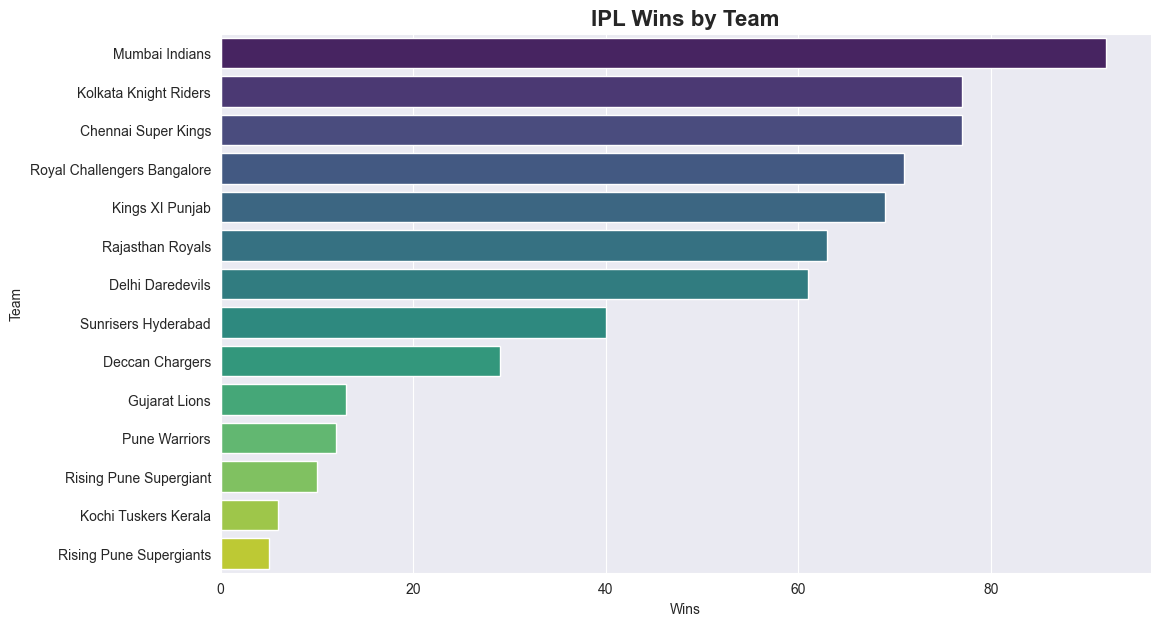

In [11]:
plt.figure(figsize=(12,7))
sns.set_style("darkgrid")

sns.countplot(
    y='winner',
    data=data,
    order=data['winner'].value_counts().index,
    palette='viridis'
)

plt.title('IPL Wins by Team', fontsize=16, fontweight='bold')
plt.xlabel('Wins')
plt.ylabel('Team')

plt.show()

Text(0.5, 1.0, 'Total Number of matches played in different stadium')

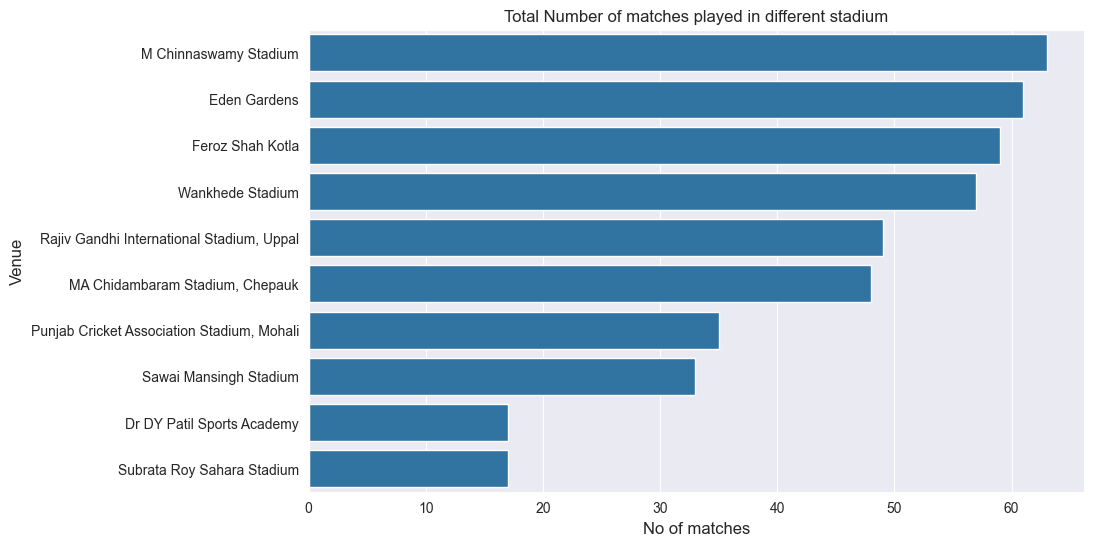

In [12]:
plt.figure(figsize = (10,6))
sns.countplot(y = 'venue',data = data,order = data['venue'].value_counts().iloc[:10].index)
plt.xlabel('No of matches',fontsize=12)
plt.ylabel('Venue',fontsize=12)
plt.title('Total Number of matches played in different stadium')

C:\Users\rohit\AppData\Local\Temp\ipykernel_19624\3182758372.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


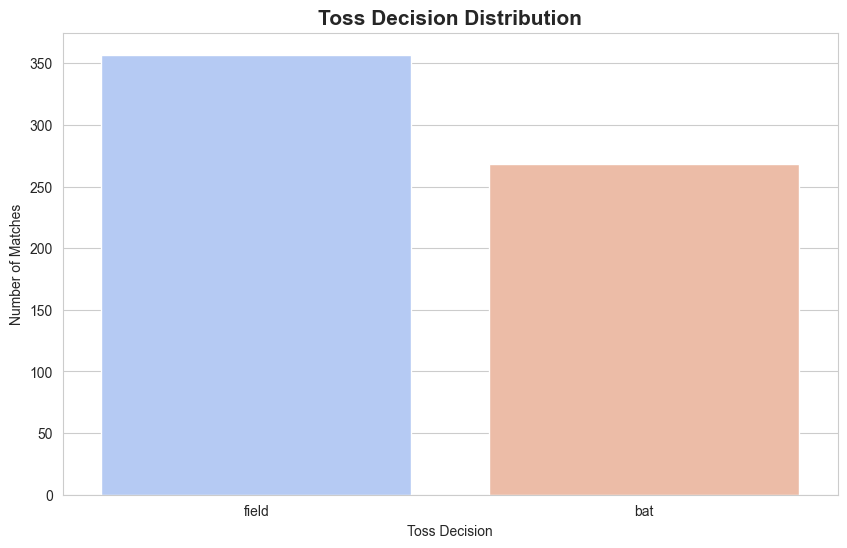

In [13]:
plt.figure(figsize=(10,6))
sns.set_style("whitegrid")

sns.countplot(
    x="toss_decision",
    data=data,
    palette="coolwarm"
)

plt.title('Toss Decision Distribution', fontsize=15, fontweight='bold')
plt.xlabel('Toss Decision')
plt.ylabel('Number of Matches')

plt.show()

In [14]:
x = ["city", "toss_decision", "result", "dl_applied"]

for i in x:
    print("------------")
    print(data[i].unique())
    print(data[i].value_counts())

------------
<ArrowStringArray>
[     'Hyderabad',           'Pune',         'Rajkot',         'Indore',
         'Mumbai',        'Kolkata',      'Bangalore',          'Delhi',
     'Chandigarh',         'Kanpur',         'Jaipur',        'Chennai',
      'Cape Town', 'Port Elizabeth',         'Durban',      'Centurion',
    'East London',   'Johannesburg',      'Kimberley',   'Bloemfontein',
      'Ahmedabad',        'Cuttack',         'Nagpur',     'Dharamsala',
          'Kochi',  'Visakhapatnam',         'Raipur',         'Ranchi',
      'Abu Dhabi',        'Sharjah']
Length: 30, dtype: str
city
Mumbai            85
Bangalore         63
Kolkata           61
Delhi             59
Hyderabad         49
Chennai           48
Chandigarh        46
Jaipur            33
Pune              32
Durban            15
Centurion         12
Ahmedabad         12
Visakhapatnam     11
Rajkot            10
Dharamsala         9
Johannesburg       8
Cape Town          7
Port Elizabeth     7
Cuttack       

In [15]:
data.drop(
    ["id", "season", "city", "date",
     "player_of_match", "umpire1",
     "venue", "umpire2"],
    axis=1,
    inplace=True
)

In [16]:
print(data.columns)

Index(['team1', 'team2', 'toss_winner', 'toss_decision', 'result',
       'dl_applied', 'winner', 'win_by_runs', 'win_by_wickets'],
      dtype='str')


In [17]:
drop_cols = ["id", "Season", "city", "date",
             "player_of_match", "umpire1",
             "venue", "umpire2"]

data.drop(columns=[col for col in drop_cols if col in data.columns], inplace=True)

In [18]:
X = data.drop(["winner"], axis=1)
y = data["winner"]

In [19]:
X = pd.get_dummies(
    X,
    columns=["team1", "team2", "toss_winner", "toss_decision", "result"],
    drop_first=True   # avoids multicollinearity (dummy variable trap)
)

print("Encoded feature shape:", X.shape)
print("Sample columns:", list(X.columns[:6]), "...")

Encoded feature shape: (625, 44)
Sample columns: ['dl_applied', 'win_by_runs', 'win_by_wickets', 'team1_Deccan Chargers', 'team1_Delhi Daredevils', 'team1_Gujarat Lions'] ...


In [20]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)

In [21]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X, y, train_size = 0.8)

In [22]:
from sklearn.ensemble import RandomForestClassifier
import numpy as np

x_train = np.array(x_train)
y_train = np.array(y_train).ravel()

model = RandomForestClassifier(
    n_estimators=200,
    min_samples_split=3,
    max_features='sqrt',
    random_state=42
)

In [23]:
model.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",3
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [24]:
y_pred = model.predict(x_test)

c:\Users\rohit\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


In [30]:
from sklearn.metrics import accuracy_score

In [34]:
accuracy_score(y_pred, y_test)

0.88

In [35]:
from sklearn.metrics import confusion_matrix

In [36]:
confusion_matrix(y_test, y_pred)

array([[17,  1,  1,  0,  0,  0,  0,  0,  0,  0,  1,  0,  0,  0],
       [ 1,  5,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  9,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1],
       [ 0,  0,  0,  1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0, 11,  0,  0,  1,  0,  0,  0,  0,  0,  0],
       [ 1,  0,  0,  0,  0,  2,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 1,  0,  0,  0,  0,  0, 14,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0, 18,  0,  0,  0,  0,  0,  0],
       [ 1,  0,  0,  0,  0,  0,  0,  0,  1,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0, 12,  0,  0,  0,  0],
       [ 2,  0,  0,  0,  0,  0,  0,  0,  0,  0,  2,  0,  0,  0],
       [ 1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, 10,  0],
       [ 1,  0,  0,  0,  1,  0,  0,  0,  0,  0,  0,  0,  1,  8]])

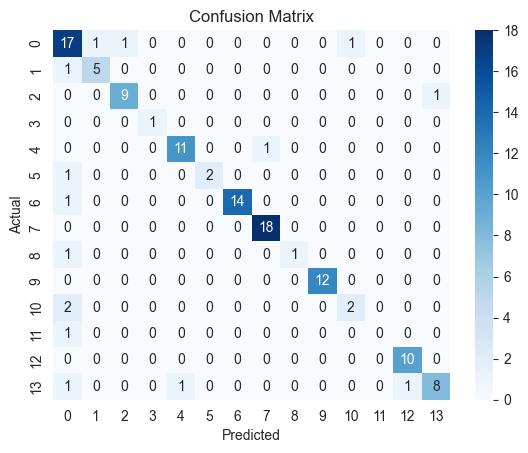

In [37]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()